# PRACTICA: Embeddings y Vector Database (Azure AI Search)

> Formato: MD. Entrega en la carpeta del tema. Esta práctica tiene dos partes: documentación del wizard (Import data) y ejecución de búsquedas.

---

## Resumen

Objetivo: Crear y documentar un pipeline de indexación por medio del wizard "Import data" del portal de Azure (vectorización integrada). Posteriormente realizar búsquedas contra el índice creado: Vector Search, Hybrid Search, Semantic Search y Semantic Hybrid Search. Incluir capturas, explicaciones y resultados.

---

## Requisitos previos

- Cuenta Azure con recurso Azure AI Search (Basic o superior recomendado).
- Contenedor en Azure Blob Storage con documentos (PDF/DOCX/HTML).
- Recurso Azure OpenAI con deployment de embeddings.

---

## PARTE 1 — Creación del índice mediante el wizard (Import data)

Esta parte es documental: seguir el wizard en el portal para crear el índice. Entregar en este archivo las capturas y explicaciones.

Pasos (portal):
1. En el recurso de **Azure AI Search** seleccionar **Import data**.
2. Elegir escenario: **RAG** (no agentic retrieval).
3. Conectar a **Azure Blob Storage** (seleccionar contenedor con documentos). Autenticación por Managed Identity o clave.
4. En vectorización elegir proveedor (Azure OpenAI / Foundry) y deployment de embeddings.
5. Revisar la inferencia del esquema y ajustar campos si hace falta.
6. Finalizar: el wizard crea Data Source, Index, Skillset (si se activó enrichment), Indexer y Knowledge Store opcional.

### Capturas y explicaciones que hay que adjuntar

- **ÍNDICE (Index schema)**: capturar la definición del índice creado.
- **SEMANTIC CONFIGURATION**: captura del objeto semántico creado. Explicar qué es y cómo está configurado.
- **VECTOR PROFILE**: captura de la sección `Algorithm` y `Vectorizer` del índice. Explicar cada una de ellas y cómo están configuradas
- **SKILLSET**: captura del skillset generado por el wizard. Explicar qué es y los pasos que contiene
---

### Evidencias y explicación (Parte 1)

#### 1) ÍNDICE (Index schema)
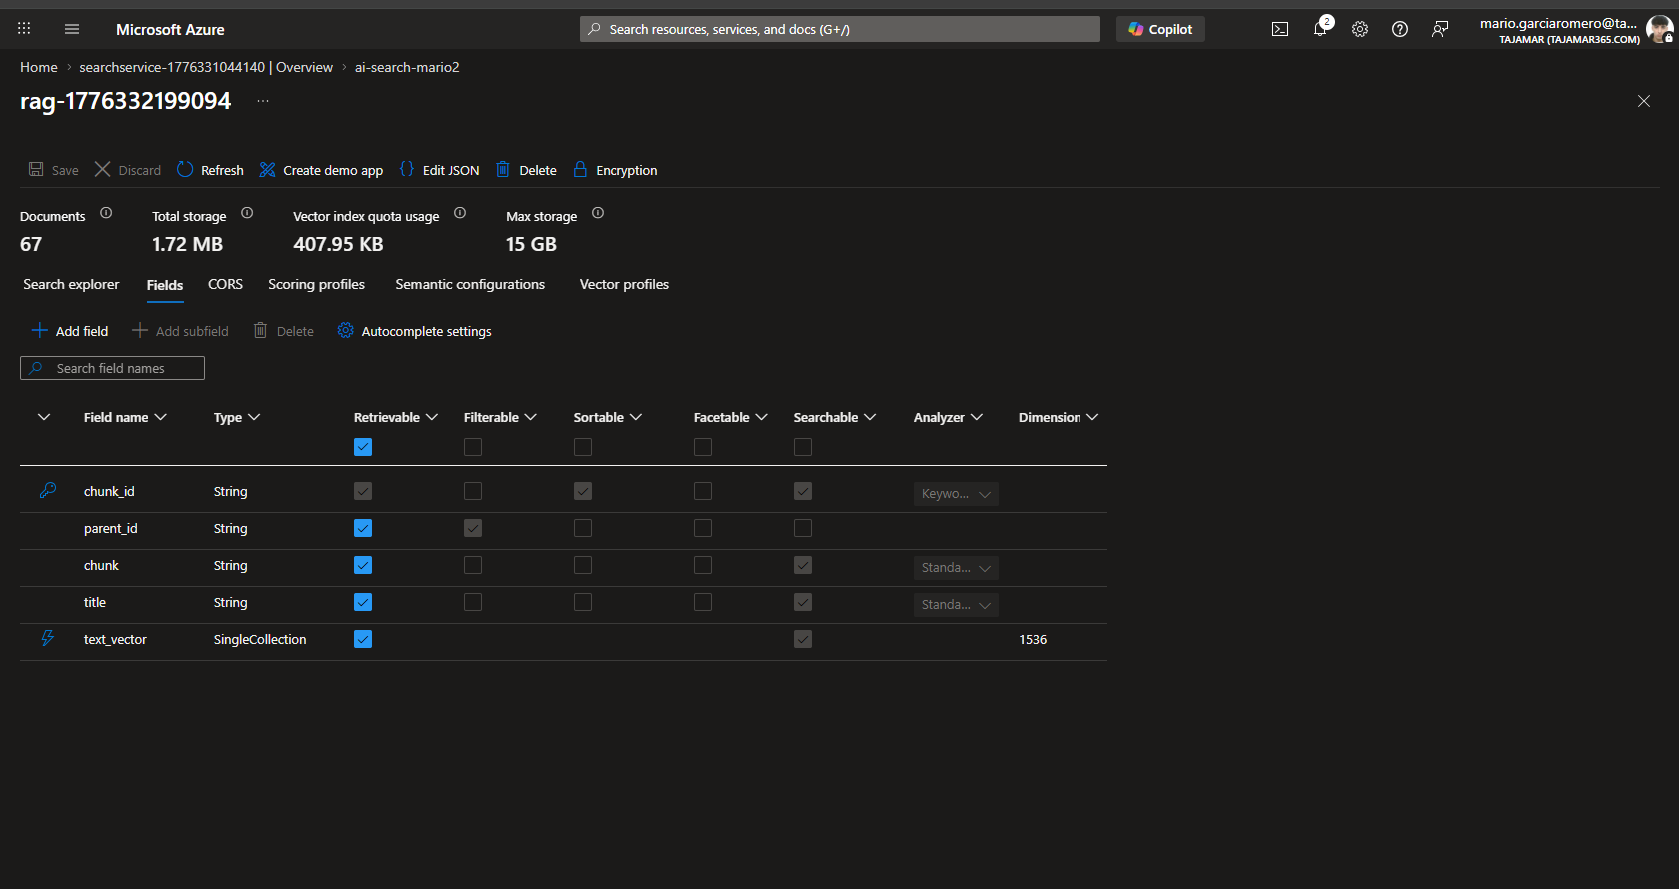

Este índice se llama **rag-1776332199094** y en la captura aparecen **67 documentos** indexados.

Campos principales observados:
- **chunk_id** (String): campo clave del documento (key). Está marcado como recuperable, ordenable y searchable. Usa analizador tipo keyword.
- **parent_id** (String): campo para relacionar fragmentos con su documento origen. Está como recuperable y filtrable.
- **chunk** (String): contiene el texto fragmentado del contenido. Está como recuperable y searchable (analizador estándar).
- **title** (String): título del documento o fragmento. Está como recuperable y searchable (analizador estándar).
- **text_vector** (Collection de float): campo vectorial para embeddings, con **dimensión 1536**.

Interpretación:
- Los campos de texto (`chunk`, `title`) soportan búsqueda textual tradicional.
- El campo `text_vector` habilita la búsqueda vectorial por similitud semántica.
- La combinación de campos textuales + vectoriales permite hacer búsqueda híbrida y mejorar resultados para escenarios RAG.

#### 2) SEMANTIC CONFIGURATION
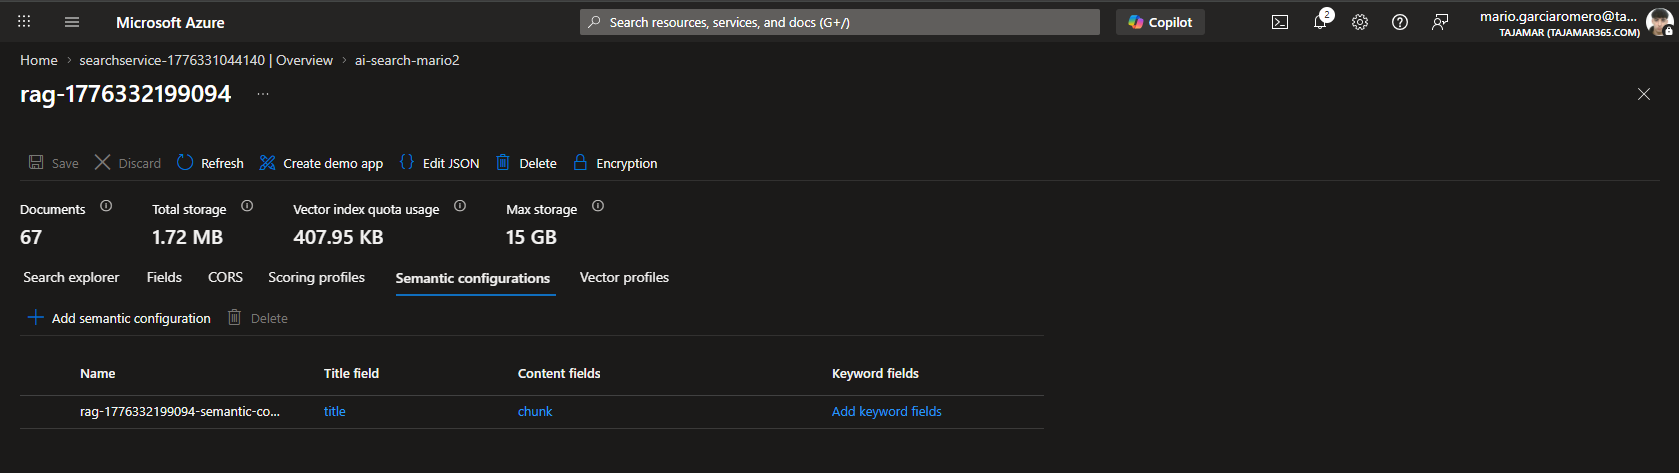

En tu índice hay una configuración semántica creada automáticamente por el wizard, con nombre **rag-1776332199094-semantic-co...**.
- **Title field**: `title`.
- **Content fields**: `chunk`.
- **Keyword fields**: no hay campos definidos (aparece la opción “Add keyword fields”).

Esto significa que, para el ranking semántico, Azure Search toma el título desde `title` y el contenido principal desde `chunk`. Aunque no se definan keyword fields, la búsqueda semántica funciona igualmente con título + contenido, y en este caso es suficiente para el escenario RAG.

#### 3) VECTOR PROFILE (Algorithm + Vectorizer)
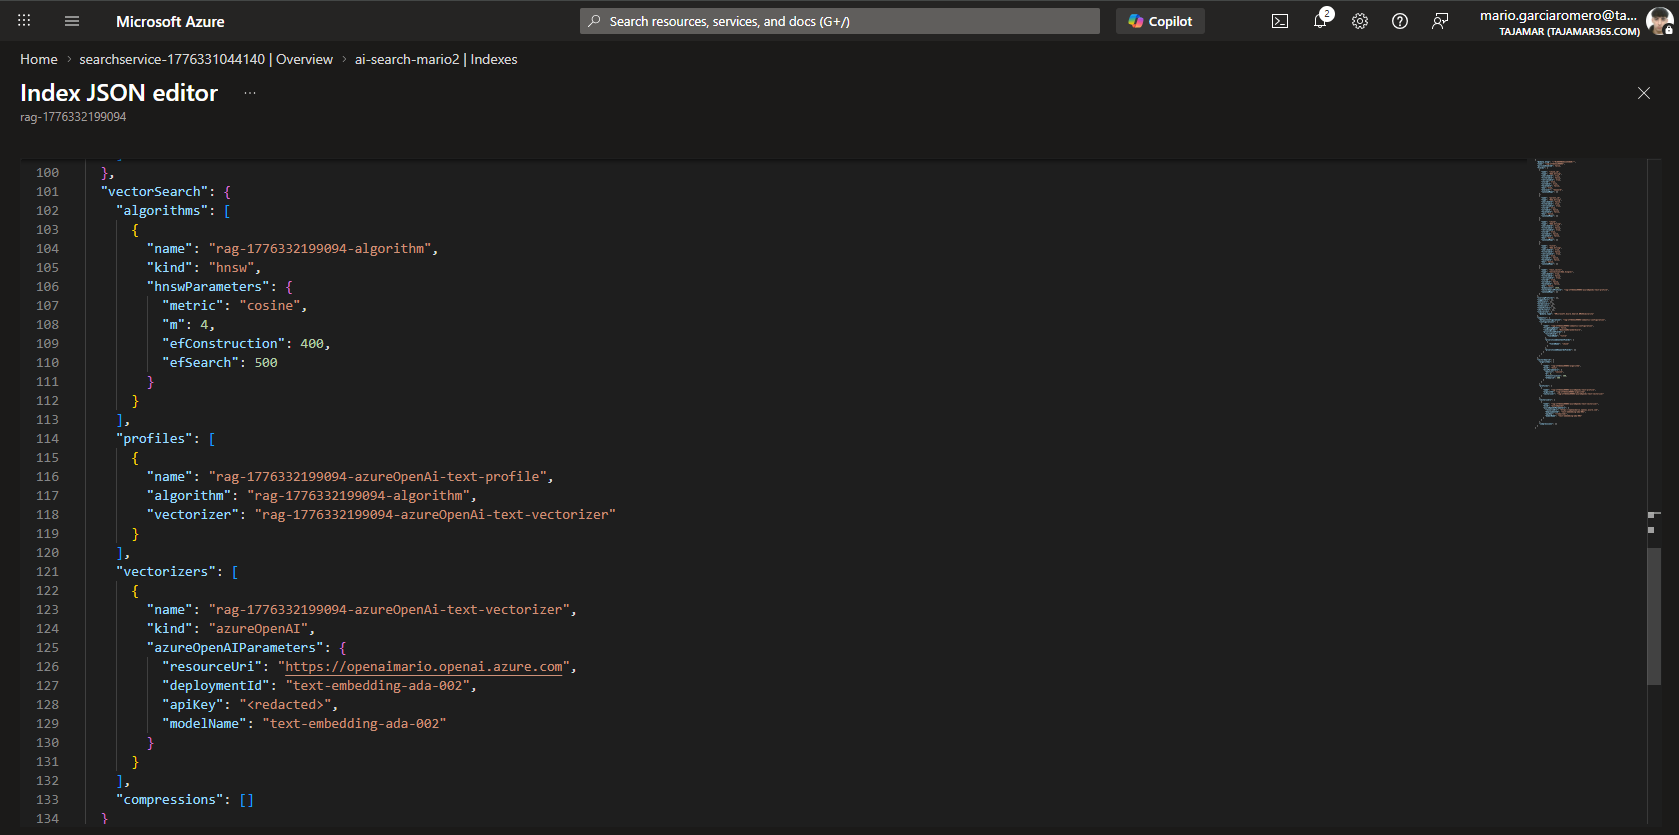

En este caso, el perfil vectorial quedó configurado así:
- **Algorithm: HNSW**. Es un algoritmo de búsqueda aproximada de vecinos cercanos (ANN) optimizado para consultas rápidas sobre vectores de alta dimensión.
- **Vectorizer: Azure OpenAI** con deployment **`text-embedding-ada-002`**.
- **Servicio usado**: **`openAiMario`** (suscripción **Azure - Tajamar**).
- **Autenticación**: **System assigned identity** (identidad administrada del recurso).

Con esta configuración, durante la indexación y consulta el texto se convierte a embeddings con Azure OpenAI y luego se recuperan documentos por similitud usando HNSW.

#### 4) SKILLSET
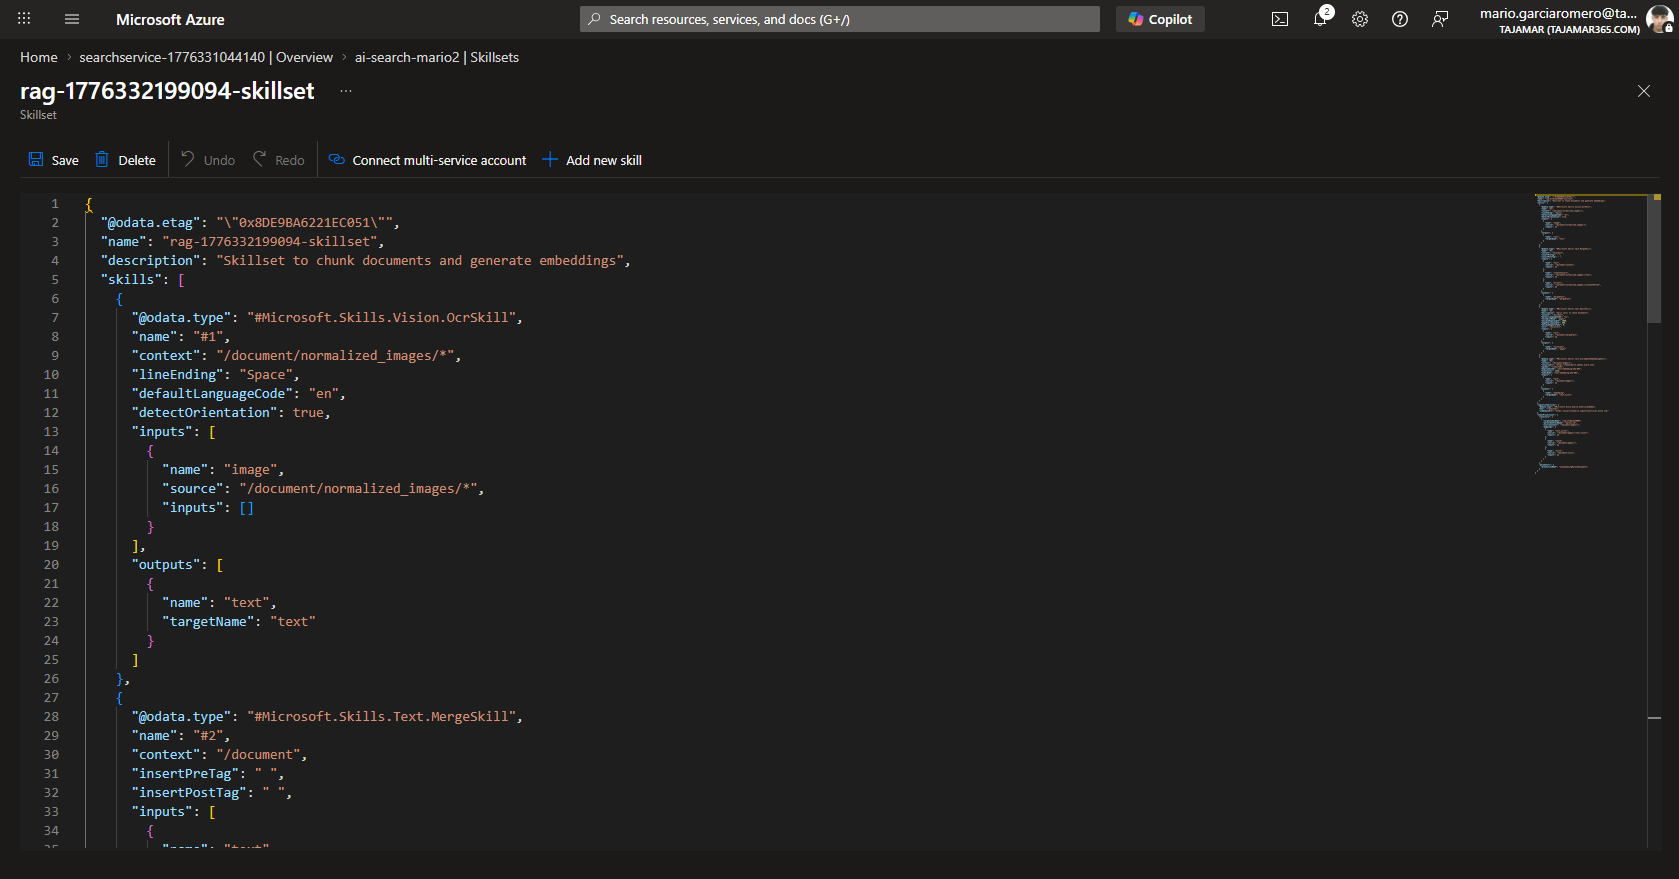

El skillset creado es **rag-1776332199094-skillset** y su objetivo es *chunk documents and generate embeddings*.

Pipeline de skills (en orden):
- **#1 OcrSkill** (`/document/normalized_images/*`): extrae texto de imágenes normalizadas, con idioma por defecto `en` y detección de orientación activada.
- **#2 MergeSkill** (`/document`): fusiona el contenido original (`/document/content`) con el texto detectado por OCR para generar `mergedText`.
- **#3 SplitSkill** (`/document`): divide `mergedText` en fragmentos tipo páginas con:
  - `maximumPageLength = 2000` caracteres
  - `pageOverlapLength = 500` caracteres
  - salida en `pages`
- **#4 AzureOpenAIEmbeddingSkill** (`/document/pages/*`): genera embeddings con:
  - recurso `https://openaimario.openai.azure.com`
  - modelo/deployment `text-embedding-ada-002`
  - `dimensions = 1536`
  - salida `text_vector`

Además, usa **Azure AI Services** como recurso cognitivo para el procesamiento enriquecido.

**Index projections** al índice `rag-1776332199094`:
- `parent_id` como clave padre
- Desde cada página (`/document/pages/*`) se proyectan:
  - `text_vector` <- `/document/pages/*/text_vector`
  - `chunk` <- `/document/pages/*`
  - `title` <- `/document/title`
- Modo de proyección: `skipIndexingParentDocuments`

Resultado: cada documento se transforma en varios chunks con solapamiento, cada chunk obtiene su embedding y se indexa como unidad de recuperación para búsquedas vectoriales e híbridas en RAG.